In [ ]:
import numpy as np
from Solver.AdvReactUni import AdvReactUni1DSolver, AdvReactUni1DEval
from Solver.FVUni2nd import FVUni2nd1D
from Solver.ODE import ESDIRK, DITRExp

Nx = 128

fv = FVUni2nd1D(nx=Nx)
ev = AdvReactUni1DEval(
    fv=fv,
    # model="bistable",
    # params={"a": 0.5, "k": 100},
)
# solver = AdvReactUni1DSolver(eval=ev, ode=ESDIRK("BackwardEuler"))
solver = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

dt = 1 / Nx * 0.5 * 1
tEnd = 1

u = np.array([np.sin(fv.xcs * np.pi * 2)]) * 0 + 1

# u1 = solver.stepInterval(dt, u, 0.0, tEnd)

solverDITR = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

u1Ditr = solverDITR.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-8,
        "CFL": 10,
    },
    use_exp=True,
)

iter [[0.5, 1],9], resN [4.2855e-07 / 4.8805e+01]
Step [1], t = [3.9062e-03] uNorm [13.829786752877993]
iter [[0.5, 1],10], resN [1.3870e-06 / 4.8711e+01]
iter [[0.5, 1],11], resN [4.5528e-07 / 4.8711e+01]
Step [2], t = [7.8125e-03] uNorm [13.803218182858545]
iter [[0.5, 1],9], resN [2.5521e-07 / 4.8617e+01]
Step [3], t = [1.1719e-02] uNorm [13.776700673020212]
iter [[0.5, 1],10], resN [9.6348e-07 / 4.8523e+01]
iter [[0.5, 1],11], resN [2.8752e-07 / 4.8523e+01]
Step [4], t = [1.5625e-02] uNorm [13.750234048524757]
iter [[0.5, 1],9], resN [1.9590e-07 / 4.8430e+01]
Step [5], t = [1.9531e-02] uNorm [13.723818319042302]
iter [[0.5, 1],10], resN [4.8332e-07 / 4.8337e+01]
Step [6], t = [2.3438e-02] uNorm [13.697453283401961]
iter [[0.5, 1],9], resN [3.6275e-07 / 4.8244e+01]
Step [7], t = [2.7344e-02] uNorm [13.67113894372634]
iter [[0.5, 1],9], resN [2.9440e-07 / 4.8151e+01]
Step [8], t = [3.1250e-02] uNorm [13.644875117496715]
iter [[0.5, 1],10], resN [2.0040e-06 / 4.8058e+01]
iter [[0.5, 1

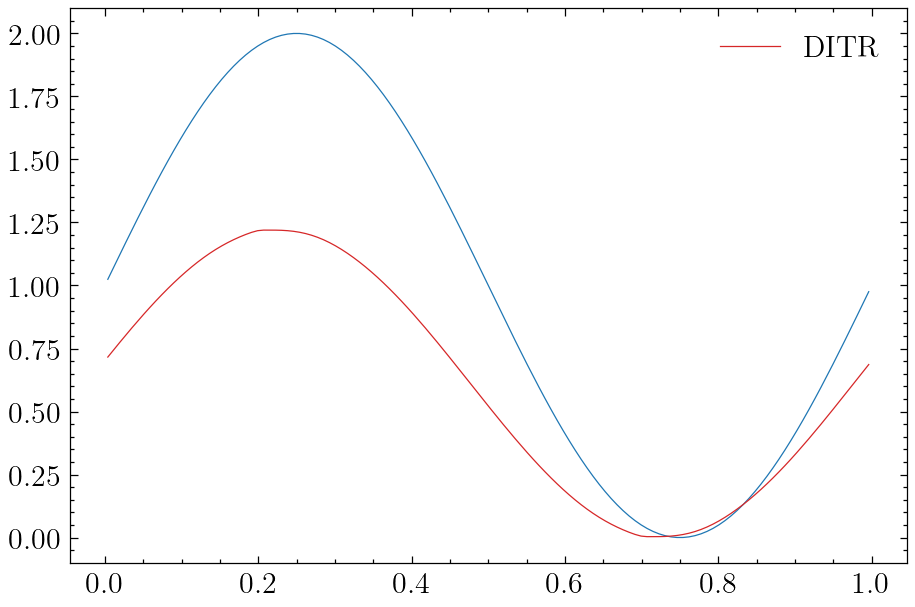

In [6]:
import matplotlib.pyplot as plt
import PlotEnv

plotEnv = PlotEnv.PlotEnv(dpi=180, markEvery=0)

fig = plotEnv.figure(101, figsize=(6, 4))
plotEnv.plot(fv.xcs, u[0], plotIndex=0)
plotEnv.plot(fv.xcs, u1Ditr[0], plotIndex=3, label="DITR")
plt.legend()
plt.show()